<a href="https://colab.research.google.com/github/Wizako-01/beyond-accuracy-cxr-uncertainty/blob/main/ICID_XRAY_WORK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aminumusa/nigeria-chest-x-ray-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'nigeria-chest-x-ray-dataset' dataset.
Path to dataset files: /kaggle/input/nigeria-chest-x-ray-dataset


In [4]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/aminumusa/nigeria-chest-x-ray-dataset/versions/1"

for root, dirs, files in os.walk(dataset_path):
    print("Root:", root)
    print("Folders:", dirs)
    print("Number of files:", len(files))
    print("Sample files:", files[:5])
    print("-" * 50)
    break

Root: /root/.cache/kagglehub/datasets/aminumusa/nigeria-chest-x-ray-dataset/versions/1
Folders: ['my_dataset']
Number of files: 0
Sample files: []
--------------------------------------------------


In [5]:

for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)
    print(item, "->", "Folder" if os.path.isdir(item_path) else "File")

    if os.path.isdir(item_path):
        print("   Contains:", os.listdir(item_path)[:10])

my_dataset -> Folder
   Contains: ['test_folder', 'train_folder']


In [6]:

import os

dataset_path = "/root/.cache/kagglehub/datasets/aminumusa/nigeria-chest-x-ray-dataset/versions/1/my_dataset"

train_path = os.path.join(dataset_path, "train_folder")
test_path = os.path.join(dataset_path, "test_folder")

print("Train classes:", os.listdir(train_path))
print("Test classes:", os.listdir(test_path))

Train classes: ['PNEUMONIA', 'COVID', 'NORMAL', 'TB']
Test classes: ['PNEUMONIA', 'COVID', 'NORMAL', 'TB']


In [7]:

for split_name, split_path in [("Train", train_path), ("Test", test_path)]:
    print(f"\n{split_name} set:")
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            print(f"{class_name}: {num_images} images")


Train set:
PNEUMONIA: 500 images
COVID: 500 images
NORMAL: 500 images
TB: 500 images

Test set:
PNEUMONIA: 150 images
COVID: 150 images
NORMAL: 150 images
TB: 150 images


In [8]:

import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Paths
dataset_path = "/root/.cache/kagglehub/datasets/aminumusa/nigeria-chest-x-ray-dataset/versions/1/my_dataset"
train_path = os.path.join(dataset_path, "train_folder")
test_path = os.path.join(dataset_path, "test_folder")

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # convert grayscale CXR to 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Full training dataset
full_train_dataset = datasets.ImageFolder(root=train_path, transform=transform)

# Test dataset
test_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Split training into train + validation
train_size = int(0.8 * len(full_train_dataset))   # 1600
val_size = len(full_train_dataset) - train_size   # 400

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Check classes and sizes
print("Classes:", full_train_dataset.classes)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Classes: ['COVID', 'NORMAL', 'PNEUMONIA', 'TB']
Training samples: 1600
Validation samples: 400
Test samples: 600


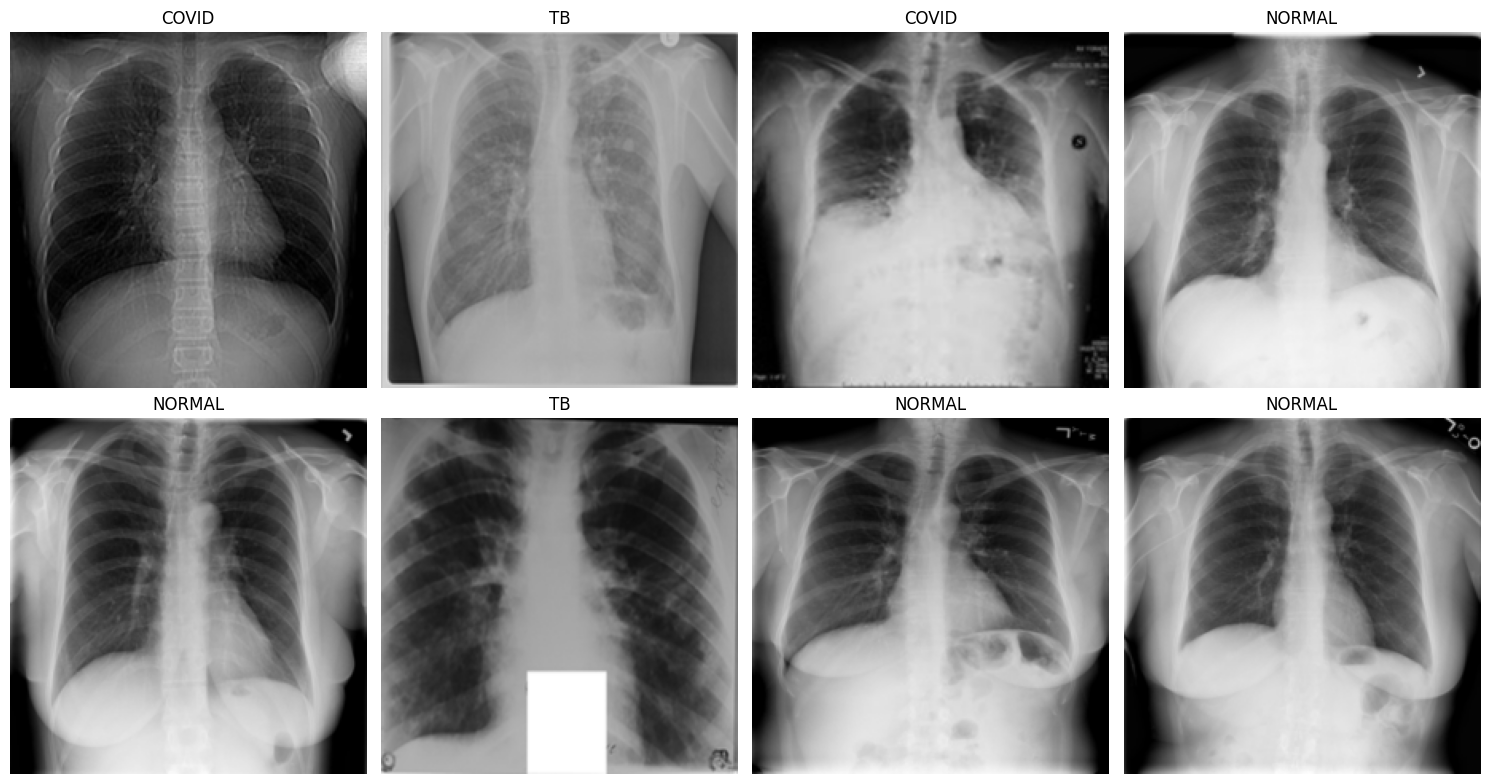

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from train_loader
images, labels = next(iter(train_loader))

# Class names
class_names = full_train_dataset.classes

# Show first 8 images
plt.figure(figsize=(15, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)

    # Convert tensor to numpy and move channel dimension last
    img = images[i].permute(1, 2, 0).numpy()

    # Undo normalization for display
    img = (img * 0.5) + 0.5
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
import os

model_path = "/content/hybrid_densenet_vit_tiny.pth"

print("Exists:", os.path.exists(model_path))
print("Size in bytes:", os.path.getsize(model_path))
print("Size in MB:", os.path.getsize(model_path) / (1024 * 1024))

Exists: True
Size in bytes: 50331648
Size in MB: 48.0


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import torch
import os

model_path = "/content/drive/MyDrive/Vit Model/hybrid_densenet_vit_tiny.pth"

print("Exists:", os.path.exists(model_path))
print("Size (MB):", os.path.getsize(model_path) / (1024 * 1024))

try:
    checkpoint = torch.load(model_path, map_location="cpu")
    print("Checkpoint loaded successfully.")
    print("Type:", type(checkpoint))

    if isinstance(checkpoint, dict):
        print("First keys:")
        print(list(checkpoint.keys())[:20])

except Exception as e:
    print("Loading failed:")
    print(e)

Exists: True
Size (MB): 50.64438438415527
Checkpoint loaded successfully.
Type: <class 'collections.OrderedDict'>
First keys:
['densenet.features.conv0.weight', 'densenet.features.norm0.weight', 'densenet.features.norm0.bias', 'densenet.features.norm0.running_mean', 'densenet.features.norm0.running_var', 'densenet.features.norm0.num_batches_tracked', 'densenet.features.denseblock1.denselayer1.norm1.weight', 'densenet.features.denseblock1.denselayer1.norm1.bias', 'densenet.features.denseblock1.denselayer1.norm1.running_mean', 'densenet.features.denseblock1.denselayer1.norm1.running_var', 'densenet.features.denseblock1.denselayer1.norm1.num_batches_tracked', 'densenet.features.denseblock1.denselayer1.conv1.weight', 'densenet.features.denseblock1.denselayer1.norm2.weight', 'densenet.features.denseblock1.denselayer1.norm2.bias', 'densenet.features.denseblock1.denselayer1.norm2.running_mean', 'densenet.features.denseblock1.denselayer1.norm2.running_var', 'densenet.features.denseblock1.dense

In [14]:
# =========================================================
# BLOCK 1: HYBRID MODEL + BASELINE TEST
# =========================================================

!pip install timm -q

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Class names
class_names = full_train_dataset.classes
print("Classes:", class_names)

# ---------------------------------------------------------
# HYBRID MODEL DEFINITION
# ---------------------------------------------------------
class DenseNetViTHybrid(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.densenet = models.densenet121(
            weights=models.DenseNet121_Weights.DEFAULT
        )
        densenet_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Identity()

        self.vit = timm.create_model(
            "vit_tiny_patch16_224",
            pretrained=True,
            num_classes=0
        )
        vit_features = self.vit.num_features

        self.classifier = nn.Sequential(
            nn.Linear(densenet_features + vit_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        dense_feat = self.densenet(x)
        vit_feat = self.vit(x)
        fused = torch.cat((dense_feat, vit_feat), dim=1)
        out = self.classifier(fused)
        return out

# ---------------------------------------------------------
# LOAD THE MODEL
# ---------------------------------------------------------
model_path = "/content/drive/MyDrive/Vit Model/hybrid_densenet_vit_tiny.pth"

hybrid_model = DenseNetViTHybrid(num_classes=4).to(device)
hybrid_model.load_state_dict(torch.load(model_path, map_location=device))
hybrid_model.eval()

print("Hybrid model loaded successfully from:", model_path)

# ---------------------------------------------------------
# BASELINE TEST EVALUATION
# ---------------------------------------------------------
all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = hybrid_model(images)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

baseline_acc = accuracy_score(all_labels, all_preds)
baseline_cm = confusion_matrix(all_labels, all_preds)

all_labels_onehot = label_binarize(all_labels, classes=[0, 1, 2, 3])
baseline_auc = roc_auc_score(
    all_labels_onehot,
    all_probs,
    multi_class="ovr",
    average="macro"
)

print("\n==============================")
print("BASELINE HYBRID MODEL RESULTS")
print("==============================")
print(f"Accuracy: {baseline_acc:.4f}")
print(f"Macro AUC: {baseline_auc:.5f}")

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("\nConfusion Matrix:\n")
print(baseline_cm)

Using device: cuda
Classes: ['COVID', 'NORMAL', 'PNEUMONIA', 'TB']


Hybrid model loaded successfully from: /content/drive/MyDrive/Vit Model/hybrid_densenet_vit_tiny.pth

BASELINE HYBRID MODEL RESULTS
Accuracy: 0.9900
Macro AUC: 0.99959

Classification Report:

              precision    recall  f1-score   support

       COVID       0.99      0.97      0.98       150
      NORMAL       0.99      1.00      1.00       150
   PNEUMONIA       0.98      1.00      0.99       150
          TB       0.99      0.99      0.99       150

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600


Confusion Matrix:

[[146   0   3   1]
 [  0 150   0   0]
 [  0   0 150   0]
 [  1   1   0 148]]


In [15]:
# =========================================================
# BLOCK 2: MC DROPOUT UNCERTAINTY
# =========================================================

def enable_dropout(model):
    """
    Enable dropout during test time.
    """
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()

def mc_dropout_predict(model, inputs, mc_passes=30):
    """
    Returns:
        mean_probs   : mean class probabilities
        pred_classes : predicted class
        pred_conf    : max mean probability
        pred_entropy : predictive entropy
        var_probs    : variance across passes
    """
    model.eval()
    enable_dropout(model)

    probs_list = []

    with torch.no_grad():
        for _ in range(mc_passes):
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            probs_list.append(probs.unsqueeze(0))

    probs_stack = torch.cat(probs_list, dim=0)   # [T, B, C]
    mean_probs = probs_stack.mean(dim=0)         # [B, C]
    var_probs = probs_stack.var(dim=0)           # [B, C]

    pred_conf, pred_classes = torch.max(mean_probs, dim=1)

    # Predictive entropy
    pred_entropy = -torch.sum(mean_probs * torch.log(mean_probs + 1e-12), dim=1)

    return mean_probs, pred_classes, pred_conf, pred_entropy, var_probs

# ---------------------------------------------------------
# RUN MC DROPOUT ON TEST SET
# ---------------------------------------------------------
mc_passes = 30

mc_labels = []
mc_preds = []
mc_mean_probs = []
mc_confidences = []
mc_entropies = []
mc_variances = []

print(f"Running MC Dropout inference with {mc_passes} passes...")

for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)

    mean_probs, preds, confs, entropies, var_probs = mc_dropout_predict(
        hybrid_model, images, mc_passes=mc_passes
    )

    mc_labels.extend(labels.cpu().numpy())
    mc_preds.extend(preds.cpu().numpy())
    mc_mean_probs.extend(mean_probs.cpu().numpy())
    mc_confidences.extend(confs.cpu().numpy())
    mc_entropies.extend(entropies.cpu().numpy())
    mc_variances.extend(var_probs.cpu().numpy())

mc_labels = np.array(mc_labels)
mc_preds = np.array(mc_preds)
mc_mean_probs = np.array(mc_mean_probs)
mc_confidences = np.array(mc_confidences)
mc_entropies = np.array(mc_entropies)
mc_variances = np.array(mc_variances)

mc_acc = accuracy_score(mc_labels, mc_preds)
mc_cm = confusion_matrix(mc_labels, mc_preds)

mc_labels_onehot = label_binarize(mc_labels, classes=[0, 1, 2, 3])
mc_auc = roc_auc_score(
    mc_labels_onehot,
    mc_mean_probs,
    multi_class="ovr",
    average="macro"
)

print("\n==============================")
print("MC DROPOUT RESULTS")
print("==============================")
print(f"Accuracy: {mc_acc:.4f}")
print(f"Macro AUC: {mc_auc:.5f}")
print(f"Mean Confidence: {mc_confidences.mean():.4f}")
print(f"Mean Predictive Entropy: {mc_entropies.mean():.4f}")

print("\nClassification Report:\n")
print(classification_report(mc_labels, mc_preds, target_names=class_names))

print("\nConfusion Matrix:\n")
print(mc_cm)

Running MC Dropout inference with 30 passes...

MC DROPOUT RESULTS
Accuracy: 0.9900
Macro AUC: 0.99961
Mean Confidence: 0.9923
Mean Predictive Entropy: 0.0244

Classification Report:

              precision    recall  f1-score   support

       COVID       0.99      0.97      0.98       150
      NORMAL       0.99      1.00      1.00       150
   PNEUMONIA       0.98      1.00      0.99       150
          TB       0.99      0.99      0.99       150

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600


Confusion Matrix:

[[146   0   3   1]
 [  0 150   0   0]
 [  0   0 150   0]
 [  1   1   0 148]]


ERROR vs UNCERTAINTY ANALYSIS
Correct predictions: 594
Wrong predictions: 6

Mean entropy (correct): 0.0226
Mean entropy (wrong):   0.2002

Mean confidence (correct): 0.9930
Mean confidence (wrong):   0.9261

SELECTIVE PREDICTION RESULTS
Coverage: 1.00 | Selective Accuracy: 0.9900
Coverage: 0.95 | Selective Accuracy: 0.9947
Coverage: 0.90 | Selective Accuracy: 0.9963
Coverage: 0.85 | Selective Accuracy: 1.0000
Coverage: 0.80 | Selective Accuracy: 1.0000

CALIBRATION RESULTS
Baseline ECE: 0.0104
MC Dropout ECE: 0.0107
Baseline Brier Score: 0.0050
MC Dropout Brier Score: 0.0051


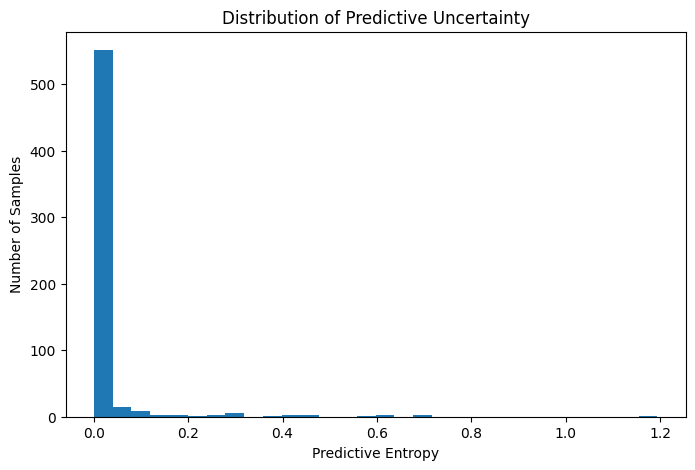

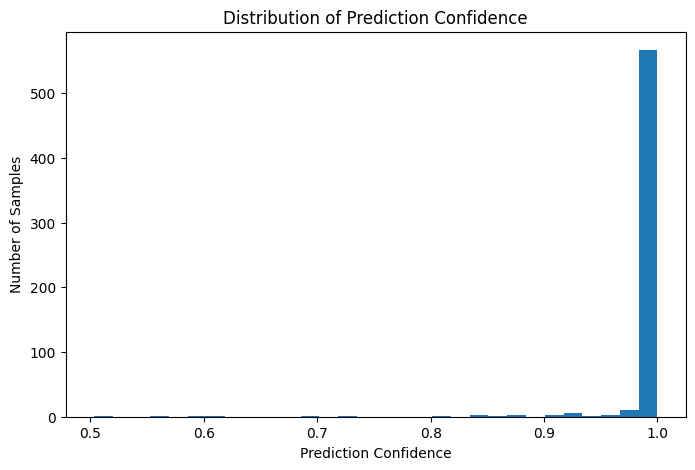

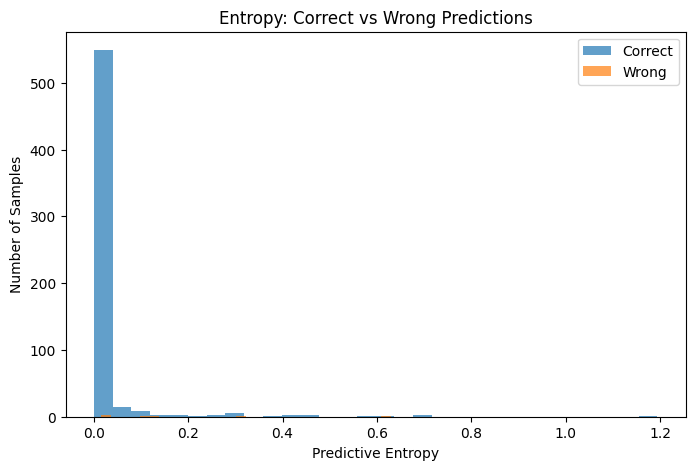

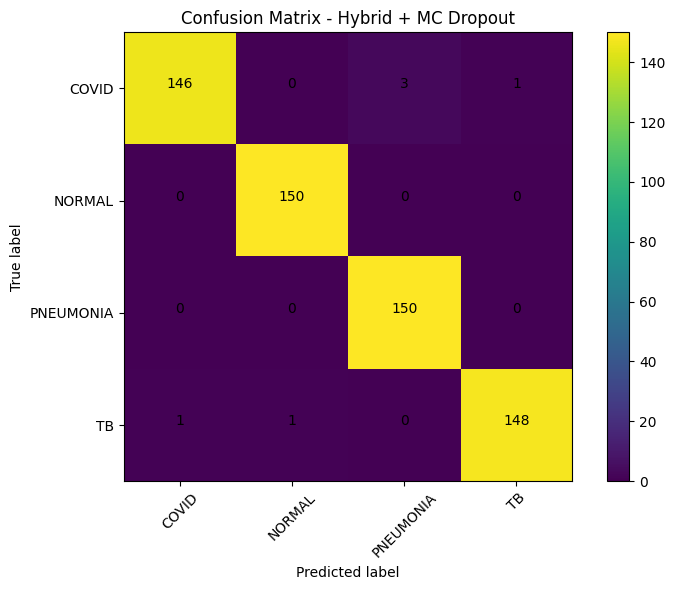

In [16]:
# =========================================================
# BLOCK 3: RELIABILITY ANALYSIS + CALIBRATION + PLOTS
# =========================================================

from sklearn.metrics import brier_score_loss

# ---------------------------------------------------------
# ERROR vs UNCERTAINTY
# ---------------------------------------------------------
correct_mask = (mc_preds == mc_labels)
wrong_mask = ~correct_mask

print("==============================")
print("ERROR vs UNCERTAINTY ANALYSIS")
print("==============================")
print("Correct predictions:", correct_mask.sum())
print("Wrong predictions:", wrong_mask.sum())

if wrong_mask.sum() > 0:
    print(f"\nMean entropy (correct): {mc_entropies[correct_mask].mean():.4f}")
    print(f"Mean entropy (wrong):   {mc_entropies[wrong_mask].mean():.4f}")

    print(f"\nMean confidence (correct): {mc_confidences[correct_mask].mean():.4f}")
    print(f"Mean confidence (wrong):   {mc_confidences[wrong_mask].mean():.4f}")
else:
    print("No wrong predictions found.")

# ---------------------------------------------------------
# SELECTIVE PREDICTION / REFERRAL ANALYSIS
# ---------------------------------------------------------
def selective_accuracy_by_entropy(y_true, y_pred, entropy_scores, retain_fraction=0.9):
    n = len(entropy_scores)
    k = int(retain_fraction * n)

    sorted_idx = np.argsort(entropy_scores)   # low entropy = more certain
    keep_idx = sorted_idx[:k]

    kept_true = y_true[keep_idx]
    kept_pred = y_pred[keep_idx]

    acc = accuracy_score(kept_true, kept_pred)
    coverage = len(keep_idx) / n
    return acc, coverage

print("\n==============================")
print("SELECTIVE PREDICTION RESULTS")
print("==============================")
for frac in [1.00, 0.95, 0.90, 0.85, 0.80]:
    sel_acc, cov = selective_accuracy_by_entropy(
        mc_labels, mc_preds, mc_entropies, retain_fraction=frac
    )
    print(f"Coverage: {cov:.2f} | Selective Accuracy: {sel_acc:.4f}")

# ---------------------------------------------------------
# CALIBRATION METRICS
# ---------------------------------------------------------
def calculate_ece(y_true, y_probs, n_bins=10):
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    confidences = np.max(y_probs, axis=1)
    predictions = np.argmax(y_probs, axis=1)
    accuracies = (predictions == y_true)

    ece = 0.0
    for bin_lower, bin_upper in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(accuracies[in_bin])
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece

def multiclass_brier_score(y_true, y_probs):
    scores = []
    for i in range(y_probs.shape[1]):
        y_bin = (y_true == i).astype(int)
        scores.append(brier_score_loss(y_bin, y_probs[:, i]))
    return np.mean(scores)

baseline_ece = calculate_ece(all_labels, all_probs)
mc_ece = calculate_ece(mc_labels, mc_mean_probs)

baseline_brier = multiclass_brier_score(all_labels, all_probs)
mc_brier = multiclass_brier_score(mc_labels, mc_mean_probs)

print("\n==============================")
print("CALIBRATION RESULTS")
print("==============================")
print(f"Baseline ECE: {baseline_ece:.4f}")
print(f"MC Dropout ECE: {mc_ece:.4f}")
print(f"Baseline Brier Score: {baseline_brier:.4f}")
print(f"MC Dropout Brier Score: {mc_brier:.4f}")

# ---------------------------------------------------------
# PLOTS
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(mc_entropies, bins=30)
plt.xlabel("Predictive Entropy")
plt.ylabel("Number of Samples")
plt.title("Distribution of Predictive Uncertainty")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(mc_confidences, bins=30)
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Samples")
plt.title("Distribution of Prediction Confidence")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(mc_entropies[correct_mask], bins=30, alpha=0.7, label="Correct")
if wrong_mask.sum() > 0:
    plt.hist(mc_entropies[wrong_mask], bins=30, alpha=0.7, label="Wrong")
plt.xlabel("Predictive Entropy")
plt.ylabel("Number of Samples")
plt.title("Entropy: Correct vs Wrong Predictions")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(mc_cm, interpolation='nearest')
plt.title("Confusion Matrix - Hybrid + MC Dropout")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i in range(mc_cm.shape[0]):
    for j in range(mc_cm.shape[1]):
        plt.text(j, i, format(mc_cm[i, j], 'd'), horizontalalignment="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()